===== DATASET =====
   Experience  Salary
0           1   25000
1           2   28000
2           3   32000
3           4   39000
4           5   48000
5           6   60000
6           7   75000
7           8   93000
8           9  114000
9          10  138000

===== LINEAR REGRESSION =====
R² Score: 0.9267
Adjusted R²: 0.9176

===== POLYNOMIAL REGRESSION =====
R² Score: 0.9998
Adjusted R²: 0.9997


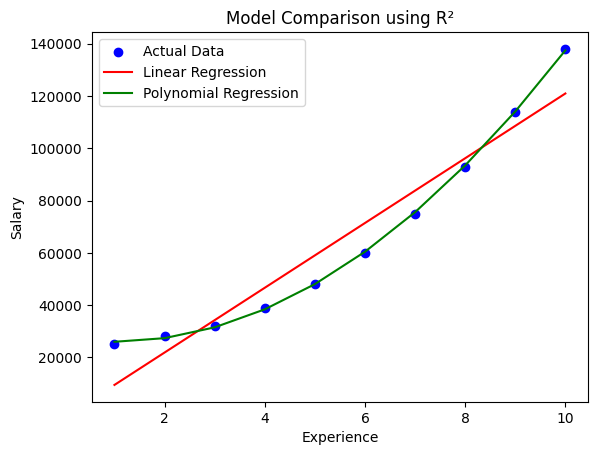

NameError: name '________________________________________' is not defined

In [1]:
# ==========================================
# R² SCORE & ADJUSTED R²
# REAL-LIFE EXAMPLE: Experience vs Salary
# ==========================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Step 2: Create dataset
data = {
    "Experience": [1,2,3,4,5,6,7,8,9,10],
    "Salary":     [25000,28000,32000,39000,48000,60000,75000,93000,114000,138000]
}

df = pd.DataFrame(data)

print("===== DATASET =====")
print(df)

# Step 3: Define X and y
X = df[["Experience"]]
y = df["Salary"]

# ==========================================
# LINEAR REGRESSION
# ==========================================

# Step 4: Train model
linear_model = LinearRegression()
linear_model.fit(X, y)

# Step 5: Predictions
y_pred_linear = linear_model.predict(X)

# Step 6: Calculate R²
r2_linear = r2_score(y, y_pred_linear)

# ==========================================
# POLYNOMIAL REGRESSION
# ==========================================

# Step 7: Create polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Step 8: Train model
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Step 9: Predictions
y_pred_poly = poly_model.predict(X_poly)

# Step 10: Calculate R²
r2_poly = r2_score(y, y_pred_poly)

# ==========================================
# ADJUSTED R² FUNCTION
# ==========================================

def adjusted_r2(r2, n, k):
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# Step 11: Calculate Adjusted R²
n = len(y)

# For Linear Regression (1 feature)
k_linear = X.shape[1]
adj_r2_linear = adjusted_r2(r2_linear, n, k_linear)

# For Polynomial Regression (2 features: x and x²)
k_poly = X_poly.shape[1] - 1
adj_r2_poly = adjusted_r2(r2_poly, n, k_poly)

# ==========================================
# PRINT RESULTS
# ==========================================

print("\n===== LINEAR REGRESSION =====")
print("R² Score:", round(r2_linear, 4))
print("Adjusted R²:", round(adj_r2_linear, 4))

print("\n===== POLYNOMIAL REGRESSION =====")
print("R² Score:", round(r2_poly, 4))
print("Adjusted R²:", round(adj_r2_poly, 4))

# ==========================================
# VISUALIZATION
# ==========================================

plt.scatter(X, y, label="Actual Data", color="blue")

plt.plot(X, y_pred_linear, label="Linear Regression", color="red")
plt.plot(X, y_pred_poly, label="Polynomial Regression", color="green")

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Model Comparison using R²")
plt.legend()
plt.show()
